In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns  # 已移除，改用 matplotlib
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# 讀取資料
df = pd.read_csv('YRBS_2007.csv')

# 準備資料比例參數 (is_sad)
df_sad = df[['SadOrHopeless']].dropna().copy()
df_sad['is_sad'] = df_sad['SadOrHopeless'].apply(lambda x: 1 if x == 1 else 0)

# 準備資料平均數參數 (BMIPCT)
df_bmi = df[['BMIPCT']].dropna().copy()

print("✅ 套件與資料準備完成！")
print(f"📊 資料筆數: {len(df)}")
print(f"😢 悲傷資料筆數: {len(df_sad)}")
print(f"📏 BMI 資料筆數: {len(df_bmi)}")

✅ 套件與資料準備完成！
📊 資料筆數: 14041
😢 悲傷資料筆數: 13845
📏 BMI 資料筆數: 13062


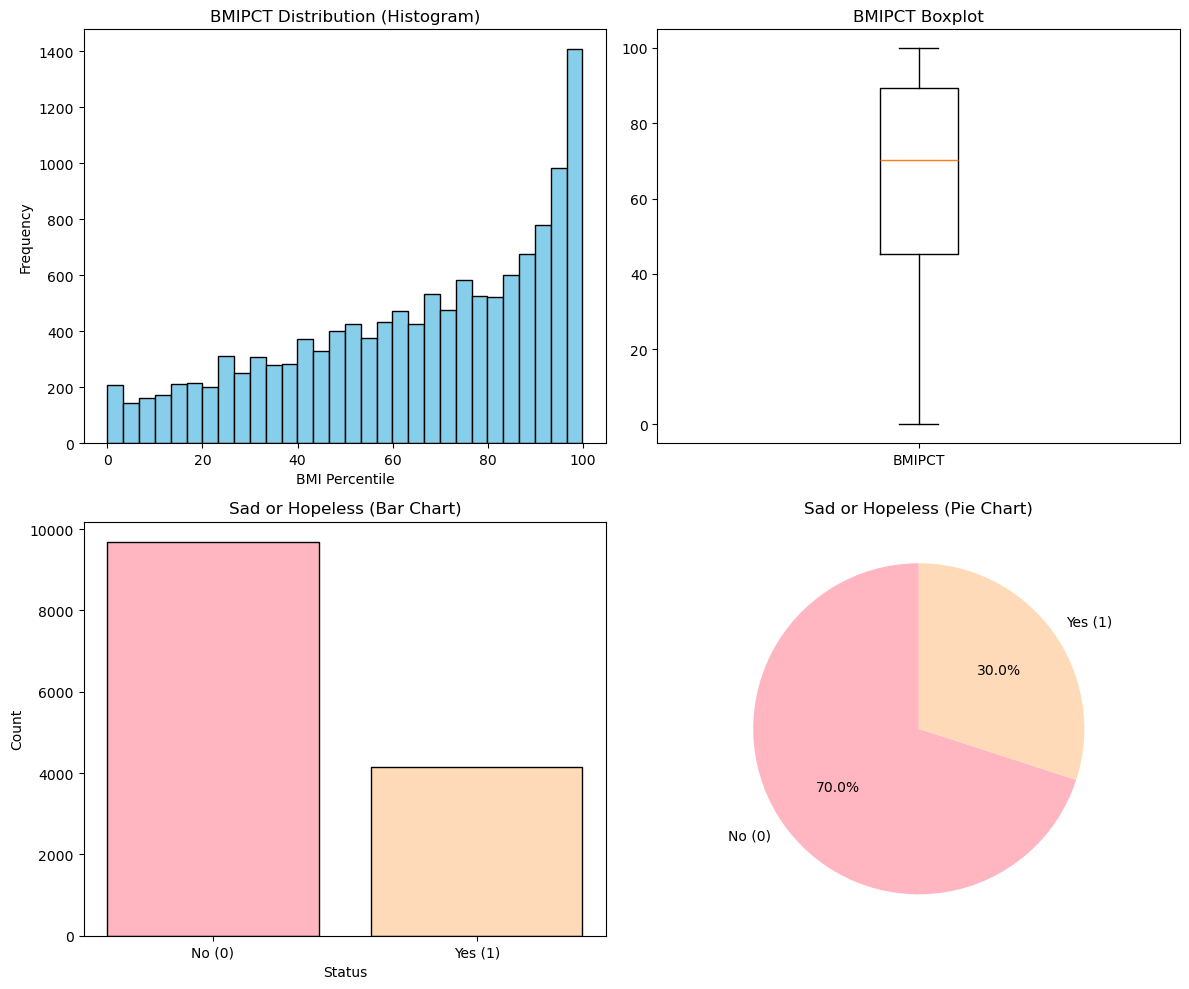

=== BMIPCT Statistics ===
count    1.306200e+04
mean     6.482068e+01
std      2.751676e+01
min      3.720000e-09
25%      4.516627e+01
50%      7.013853e+01
75%      8.945097e+01
max      9.993921e+01
Name: BMIPCT, dtype: float64

=== is_sad Statistics ===
is_sad
0    9692
1    4153
Name: count, dtype: int64


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 讀取與準備資料
# ==========================================
df = pd.read_csv('YRBS_2007.csv')

# 準備連續變數
df_bmi = df[['BMIPCT']].dropna().copy()

# 準備類別變數
df_sad = df[['SadOrHopeless']].dropna().copy()
df_sad['is_sad'] = df_sad['SadOrHopeless'].apply(lambda x: 1 if x == 1 else 0)

# ==========================================
# 2. 繪製最基礎穩定的視覺化圖表 (2x2 畫布)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# [圖 1 左上] BMIPCT 直方圖 (純 Matplotlib)
axes[0, 0].hist(df_bmi['BMIPCT'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('BMIPCT Distribution (Histogram)')
axes[0, 0].set_xlabel('BMI Percentile')
axes[0, 0].set_ylabel('Frequency')

# [圖 2 右上] BMIPCT 箱型圖 (純 Matplotlib)
axes[0, 1].boxplot(df_bmi['BMIPCT'], vert=True)
axes[0, 1].set_title('BMIPCT Boxplot')
axes[0, 1].set_xticks([1])
axes[0, 1].set_xticklabels(['BMIPCT'])

# [圖 3 左下] is_sad 長條圖 (純 Matplotlib)
sad_counts = df_sad['is_sad'].value_counts().sort_index()
axes[1, 0].bar(['No (0)', 'Yes (1)'], sad_counts.values, color=['lightpink', 'peachpuff'], edgecolor='black')
axes[1, 0].set_title('Sad or Hopeless (Bar Chart)')
axes[1, 0].set_xlabel('Status')
axes[1, 0].set_ylabel('Count')

# [圖 4 右下] is_sad 圓餅圖 (純 Matplotlib)
axes[1, 1].pie(sad_counts.values, labels=['No (0)', 'Yes (1)'], autopct='%1.1f%%', 
               colors=['lightpink', 'peachpuff'], startangle=90)
axes[1, 1].set_title('Sad or Hopeless (Pie Chart)')

# 調整排版並顯示
plt.tight_layout()
plt.show()

# ==========================================
# 3. 印出敘述性統計
# ==========================================
print("=== BMIPCT Statistics ===")
print(df_bmi['BMIPCT'].describe())
print("\n=== is_sad Statistics ===")
print(sad_counts)

In [32]:
print("=== 總體比例分析 (is_sad = 1) ===")
n_sad = len(df_sad)
count_sad = df_sad['is_sad'].sum()
p_hat = count_sad / n_sad

print(f"樣本大小: {n_sad}")
print(f"樣本比例 (p-hat): {p_hat:.4f} ({p_hat*100:.2f}%)")

# 95% 置信區間
ci_low_p, ci_high_p = proportion_confint(count_sad, n_sad, alpha=0.05, method='normal')
print(f"95% 置信區間: ({ci_low_p:.4f}, {ci_high_p:.4f})")

# 單樣本 Z 檢定 (假設檢定總體比例是否等於 0.30)
p_null = 0.30
stat_p, pval_p = proportions_ztest(count_sad, n_sad, value=p_null)
print(f"單樣本 Z 檢定 (H0: p = {p_null}):")
print(f"  Z-statistic = {stat_p:.4f}")
print(f"  p-value = {pval_p:.4e}")

=== 總體比例分析 (is_sad = 1) ===
樣本大小: 13845
樣本比例 (p-hat): 0.3000 (30.00%)
95% 置信區間: (0.2923, 0.3076)
單樣本 Z 檢定 (H0: p = 0.3):
  Z-statistic = -0.0093
  p-value = 9.9260e-01


In [33]:
print("=== 總體平均數分析 (BMIPCT) ===")
n_bmi = len(df_bmi)
mean_bmi = df_bmi['BMIPCT'].mean()

print(f"樣本大小: {n_bmi}")
print(f"樣本平均數 (mean): {mean_bmi:.4f}")

# 95% 置信區間
sem_bmi = stats.sem(df_bmi['BMIPCT'])
ci_low_mu, ci_high_mu = stats.t.interval(confidence=0.95, df=n_bmi-1, loc=mean_bmi, scale=sem_bmi)
print(f"95% 置信區間: ({ci_low_mu:.4f}, {ci_high_mu:.4f})")

# 單樣本 T 檢定 (假設檢定總體平均數是否等於 50)
mu_null = 50.0
stat_mu, pval_mu = stats.ttest_1samp(df_bmi['BMIPCT'], popmean=mu_null)
print(f"單樣本 T 檢定 (H0: mu = {mu_null}):")
print(f"  T-statistic = {stat_mu:.4f}")
print(f"  p-value = {pval_mu:.4e}")

=== 總體平均數分析 (BMIPCT) ===
樣本大小: 13062
樣本平均數 (mean): 64.8207
95% 置信區間: (64.3487, 65.2926)
單樣本 T 檢定 (H0: mu = 50.0):
  T-statistic = 61.5568
  p-value = 0.0000e+00
